# **Single-LAYER RNN**

Epoch: 100 Loss: 0.9360832582201322
Epoch: 200 Loss: 0.2705948029864131
Epoch: 300 Loss: 0.10184475802385928
Epoch: 400 Loss: 0.05550842420245378
Training converged at epoch: 423

Final Loss: 0.049874655771221785

Final Predictions:
[[0.  ]
 [0.99]
 [0.01]]
[[0.01]
 [0.02]
 [0.98]]
[[0.98]
 [0.  ]
 [0.02]]


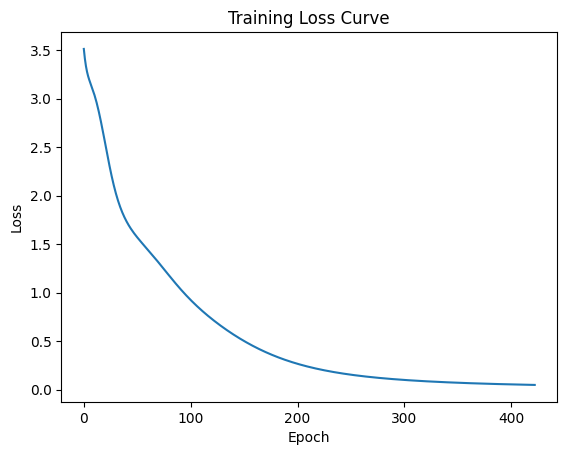

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True)

# ---------------------
# Activation Functions
# ---------------------
def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

def cross_entropy(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred + 1e-12))

# ---------------------
# Initialize RNN Parameters
# ---------------------
Wxh = np.array([[0.1, 0.2, 0.3],
                [0.4, 0.5, 0.6]])

Whh = np.array([[0.7, 0.8],
                [0.9, 1.0]])

Why = np.array([[0.1, 0.2],
                [0.3, 0.4],
                [0.5, 0.6]])

bh = np.array([[0.1],
               [0.2]])

by = np.array([[0.1],
               [0.2],
               [0.3]])

# ---------------------
# Inputs (abc)
# ---------------------
x1 = np.array([[1],[0],[0]])
x2 = np.array([[0],[1],[0]])
x3 = np.array([[0],[0],[1]])
inputs = [x1, x2, x3]

# Targets (bca)
t1 = np.array([[0],[1],[0]])
t2 = np.array([[0],[0],[1]])
t3 = np.array([[1],[0],[0]])
targets = [t1, t2, t3]

# ---------------------
# Training Parameters
# ---------------------
learning_rate = 0.1
threshold = 0.05
max_epochs = 1000
clip_value = 5

def clip_gradients(grad, clip_value):
    return np.clip(grad, -clip_value, clip_value)

loss_history = []

# =============================
# TRAINING LOOP
# =============================
for epoch in range(max_epochs):

    # ---- Forward Pass ----
    h0 = np.zeros((2,1))
    hs = [h0]
    ps = []
    loss = 0

    for t in range(3):
        ht = np.tanh(Wxh @ inputs[t] + Whh @ hs[t] + bh)
        y = Why @ ht + by
        p = softmax(y)

        hs.append(ht)
        ps.append(p)
        loss += cross_entropy(targets[t], p)

    loss_history.append(loss)

    if loss < threshold:
        print("Training converged at epoch:", epoch+1)
        break

    # ---- Backpropagation Through Time ----
    dWxh = np.zeros_like(Wxh)
    dWhh = np.zeros_like(Whh)
    dWhy = np.zeros_like(Why)
    dbh = np.zeros_like(bh)
    dby = np.zeros_like(by)

    dh_next = np.zeros((2,1))

    for t in reversed(range(3)):

        dy = ps[t] - targets[t]

        dWhy += dy @ hs[t+1].T
        dby += dy

        dh = Why.T @ dy + dh_next
        dh_raw = (1 - hs[t+1]**2) * dh

        dbh += dh_raw
        dWxh += dh_raw @ inputs[t].T
        dWhh += dh_raw @ hs[t].T

        dh_next = Whh.T @ dh_raw

    # ---- Gradient Clipping ----
    dWxh = clip_gradients(dWxh, clip_value)
    dWhh = clip_gradients(dWhh, clip_value)
    dWhy = clip_gradients(dWhy, clip_value)
    dbh = clip_gradients(dbh, clip_value)
    dby = clip_gradients(dby, clip_value)

    # ---- Update Parameters ----
    Wxh -= learning_rate * dWxh
    Whh -= learning_rate * dWhh
    Why -= learning_rate * dWhy
    bh  -= learning_rate * dbh
    by  -= learning_rate * dby

    if (epoch+1) % 100 == 0:
        print("Epoch:", epoch+1, "Loss:", loss)

print("\nFinal Loss:", loss)

# ---------------------
# Final Predictions
# ---------------------
print("\nFinal Predictions:")
for t in range(3):
    print(np.round(ps[t], 2))

# ---------------------
# Plot Loss Curve
# ---------------------
plt.plot(loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
print(Wxh)

[[-1.75341621  0.98360073  1.24598218]
 [-1.11742708  2.02919773  0.55902026]]


# **2-LAYER STACKED RNN**

Epoch: 100 Loss: 1.442926365609212
Epoch: 200 Loss: 0.7245215371359659
Epoch: 300 Loss: 0.4133097778183033
Epoch: 400 Loss: 0.28499548473681596
Epoch: 500 Loss: 0.21252865214793942
Epoch: 600 Loss: 0.09581815202159988
Training converged at epoch: 662

Final Predictions:
[[0.]
 [1.]
 [0.]]
[[0.]
 [0.]
 [1.]]
[[1.]
 [0.]
 [0.]]


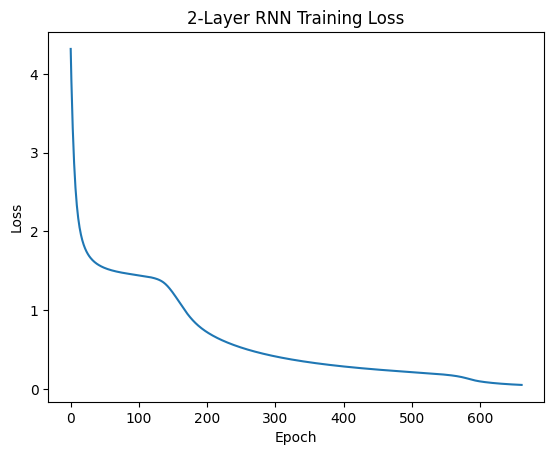

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)

# ------------------------------------------------
# Utility Functions
# ------------------------------------------------
def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

def cross_entropy(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred + 1e-12))

def clip_gradients(grad, clip_value=5):
    return np.clip(grad, -clip_value, clip_value)

# ------------------------------------------------
# Hyperparameters
# ------------------------------------------------
input_size = 3
hidden_size = 2
output_size = 3

learning_rate = 0.1
max_epochs = 1000
threshold = 0.05

np.random.seed(1)

# ------------------------------------------------
# Random Initialization
# ------------------------------------------------
Wxh1 = np.random.randn(hidden_size, input_size)
Whh1 = np.random.randn(hidden_size, hidden_size)
bh1  = np.zeros((hidden_size,1))

Wxh2 = np.random.randn(hidden_size, hidden_size)
Whh2 = np.random.randn(hidden_size, hidden_size)
bh2  = np.zeros((hidden_size,1))

Why  = np.random.randn(output_size, hidden_size)
by   = np.zeros((output_size,1))

# ------------------------------------------------
# Data (abc → bca)
# ------------------------------------------------
x1 = np.array([[1],[0],[0]])
x2 = np.array([[0],[1],[0]])
x3 = np.array([[0],[0],[1]])
inputs = [x1,x2,x3]

t1 = np.array([[0],[1],[0]])
t2 = np.array([[0],[0],[1]])
t3 = np.array([[1],[0],[0]])
targets = [t1,t2,t3]

loss_history = []

# ====================================================
# TRAINING LOOP
# ====================================================
for epoch in range(max_epochs):

    # -----------------------
    # FORWARD PASS
    # -----------------------
    h1_prev = np.zeros((hidden_size,1))
    h2_prev = np.zeros((hidden_size,1))

    hs1, hs2, ps = [], [], []
    loss = 0

    for t in range(3):

        # Layer 1
        z1 = Wxh1 @ inputs[t] + Whh1 @ h1_prev + bh1
        h1 = np.tanh(z1)

        # Layer 2
        z2 = Wxh2 @ h1 + Whh2 @ h2_prev + bh2
        h2 = np.tanh(z2)

        # Output
        y = Why @ h2 + by
        p = softmax(y)

        loss += cross_entropy(targets[t], p)

        hs1.append(h1)
        hs2.append(h2)
        ps.append(p)

        h1_prev = h1
        h2_prev = h2

    loss_history.append(loss)

    if loss < threshold:
        print("Training converged at epoch:", epoch+1)
        break

    # -----------------------
    # BACKPROPAGATION (BPTT)
    # -----------------------
    dWxh1 = np.zeros_like(Wxh1)
    dWhh1 = np.zeros_like(Whh1)
    dWxh2 = np.zeros_like(Wxh2)
    dWhh2 = np.zeros_like(Whh2)
    dWhy  = np.zeros_like(Why)

    dbh1 = np.zeros_like(bh1)
    dbh2 = np.zeros_like(bh2)
    dby  = np.zeros_like(by)

    dh1_next = np.zeros((hidden_size,1))
    dh2_next = np.zeros((hidden_size,1))

    for t in reversed(range(3)):

        # Output layer
        dy = ps[t] - targets[t]
        dWhy += dy @ hs2[t].T
        dby  += dy

        # Layer 2
        dh2 = Why.T @ dy + dh2_next
        dz2 = (1 - hs2[t]**2) * dh2

        dWxh2 += dz2 @ hs1[t].T
        dbh2  += dz2

        if t > 0:
            dWhh2 += dz2 @ hs2[t-1].T

        dh2_next = Whh2.T @ dz2

        # Vertical propagation to Layer 1
        dh1 = Wxh2.T @ dz2 + dh1_next
        dz1 = (1 - hs1[t]**2) * dh1

        dWxh1 += dz1 @ inputs[t].T
        dbh1  += dz1

        if t > 0:
            dWhh1 += dz1 @ hs1[t-1].T

        dh1_next = Whh1.T @ dz1

    # Gradient clipping
    dWxh1 = clip_gradients(dWxh1)
    dWhh1 = clip_gradients(dWhh1)
    dWxh2 = clip_gradients(dWxh2)
    dWhh2 = clip_gradients(dWhh2)
    dWhy  = clip_gradients(dWhy)
    dbh1  = clip_gradients(dbh1)
    dbh2  = clip_gradients(dbh2)
    dby   = clip_gradients(dby)

    # Update
    Wxh1 -= learning_rate * dWxh1
    Whh1 -= learning_rate * dWhh1
    Wxh2 -= learning_rate * dWxh2
    Whh2 -= learning_rate * dWhh2
    Why  -= learning_rate * dWhy
    bh1  -= learning_rate * dbh1
    bh2  -= learning_rate * dbh2
    by   -= learning_rate * dby

    if (epoch+1) % 100 == 0:
        print("Epoch:", epoch+1, "Loss:", loss)

# ------------------------------------------------
# Final Predictions
# ------------------------------------------------
print("\nFinal Predictions:")
for p in ps:
    print(np.round(p,1))

# ------------------------------------------------
# Plot Loss Curve
# ------------------------------------------------
plt.plot(loss_history)
plt.title("2-Layer RNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# **LSTM**

Epoch: 100 Loss: 3.188176351523116
Epoch: 200 Loss: 1.4667441529088663
Epoch: 300 Loss: 0.5170863366471188
Epoch: 400 Loss: 0.15346607175269186
Epoch: 500 Loss: 0.07621219220973896
Training converged at epoch: 594

Final Loss: 0.04994360295756011

Final Predictions:
[[0.  ]
 [0.99]
 [0.01]]
[[0.02]
 [0.01]
 [0.97]]
[[0.99]
 [0.  ]
 [0.01]]


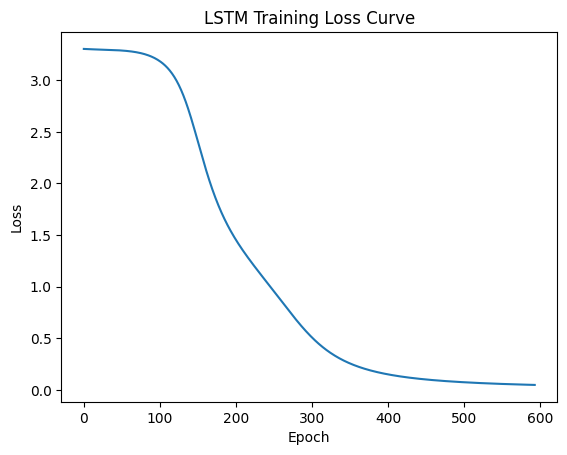

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)

# ------------------------------------------------
# Activation Functions
# ------------------------------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

def cross_entropy(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred + 1e-12))

def clip_gradients(grad, clip_value=5):
    return np.clip(grad, -clip_value, clip_value)

# ------------------------------------------------
# Hyperparameters
# ------------------------------------------------
input_size = 3
hidden_size = 2
output_size = 3

learning_rate = 0.1
max_epochs = 1000
threshold = 0.05

np.random.seed(1)

# ------------------------------------------------
# Initialize Parameters (Random)
# ------------------------------------------------
def init_gate():
    return np.random.randn(hidden_size, input_size + hidden_size) * 0.1

Wf = init_gate()
Wi = init_gate()
Wo = init_gate()
Wc = init_gate()

bf = np.zeros((hidden_size,1))
bi = np.zeros((hidden_size,1))
bo = np.zeros((hidden_size,1))
bc = np.zeros((hidden_size,1))

Why = np.random.randn(output_size, hidden_size) * 0.1
by  = np.zeros((output_size,1))

# ------------------------------------------------
# Data (abc → bca)
# ------------------------------------------------
x1 = np.array([[1],[0],[0]])
x2 = np.array([[0],[1],[0]])
x3 = np.array([[0],[0],[1]])
inputs = [x1,x2,x3]

t1 = np.array([[0],[1],[0]])
t2 = np.array([[0],[0],[1]])
t3 = np.array([[1],[0],[0]])
targets = [t1,t2,t3]

loss_history = []

# ============================================================
# TRAINING LOOP
# ============================================================
for epoch in range(max_epochs):

    # -----------------------
    # FORWARD PASS
    # -----------------------
    h = np.zeros((hidden_size,1))
    c = np.zeros((hidden_size,1))

    hs, cs, zs = [h], [c], []
    fs, ins, os, c_tildes = [], [], [], []
    ps = []
    loss = 0

    for t in range(3):

        z = np.vstack((h, inputs[t]))  # concat hidden + input
        zs.append(z)

        f = sigmoid(Wf @ z + bf)
        i = sigmoid(Wi @ z + bi)
        o = sigmoid(Wo @ z + bo)
        c_tilde = np.tanh(Wc @ z + bc)

        c = f * c + i * c_tilde
        h = o * np.tanh(c)

        y = Why @ h + by
        p = softmax(y)

        fs.append(f)
        ins.append(i)
        os.append(o)
        c_tildes.append(c_tilde)
        hs.append(h)
        cs.append(c)
        ps.append(p)

        loss += cross_entropy(targets[t], p)

    loss_history.append(loss)

    if loss < threshold:
        print("Training converged at epoch:", epoch+1)
        break

    # -----------------------
    # BACKPROPAGATION
    # -----------------------
    dWf = np.zeros_like(Wf)
    dWi = np.zeros_like(Wi)
    dWo = np.zeros_like(Wo)
    dWc = np.zeros_like(Wc)

    dbf = np.zeros_like(bf)
    dbi = np.zeros_like(bi)
    dbo = np.zeros_like(bo)
    dbc = np.zeros_like(bc)

    dWhy = np.zeros_like(Why)
    dby  = np.zeros_like(by)

    dh_next = np.zeros((hidden_size,1))
    dc_next = np.zeros((hidden_size,1))

    for t in reversed(range(3)):

        dy = ps[t] - targets[t]
        dWhy += dy @ hs[t+1].T
        dby  += dy

        dh = Why.T @ dy + dh_next
        dc = dh * os[t] * (1 - np.tanh(cs[t+1])**2) + dc_next

        # Output gate
        do = dh * np.tanh(cs[t+1])
        do_raw = do * os[t] * (1 - os[t])

        # Forget gate
        df = dc * cs[t]
        df_raw = df * fs[t] * (1 - fs[t])

        # Input gate
        di = dc * c_tildes[t]
        di_raw = di * ins[t] * (1 - ins[t])

        # Candidate
        dc_tilde = dc * ins[t]
        dc_tilde_raw = dc_tilde * (1 - c_tildes[t]**2)

        # Accumulate gradients
        dWf += df_raw @ zs[t].T
        dWi += di_raw @ zs[t].T
        dWo += do_raw @ zs[t].T
        dWc += dc_tilde_raw @ zs[t].T

        dbf += df_raw
        dbi += di_raw
        dbo += do_raw
        dbc += dc_tilde_raw

        dz = (Wf.T @ df_raw +
              Wi.T @ di_raw +
              Wo.T @ do_raw +
              Wc.T @ dc_tilde_raw)

        dh_next = dz[:hidden_size, :]
        dc_next = dc * fs[t]

    # Gradient Clipping
    for grad in [dWf,dWi,dWo,dWc,dWhy,dbf,dbi,dbo,dbc,dby]:
        np.clip(grad, -5, 5, out=grad)

    # Update
    Wf -= learning_rate * dWf
    Wi -= learning_rate * dWi
    Wo -= learning_rate * dWo
    Wc -= learning_rate * dWc
    Why -= learning_rate * dWhy
    bf -= learning_rate * dbf
    bi -= learning_rate * dbi
    bo -= learning_rate * dbo
    bc -= learning_rate * dbc
    by -= learning_rate * dby

    if (epoch+1) % 100 == 0:
        print("Epoch:", epoch+1, "Loss:", loss)

# ------------------------------------------------
# Final Results
# ------------------------------------------------
print("\nFinal Loss:", loss)

print("\nFinal Predictions:")
for p in ps:
    print(np.round(p,2))

plt.plot(loss_history)
plt.title("LSTM Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# **GRU**

Epoch: 100 Loss: 1.3290873369655272
Epoch: 200 Loss: 0.13157637445255616
Epoch: 300 Loss: 0.05990494602428699
Training converged at epoch: 336

Final Loss: 0.04981927939660494

Final Predictions:
[[0.  ]
 [0.98]
 [0.02]]
[[0.01]
 [0.01]
 [0.98]]
[[0.99]
 [0.  ]
 [0.01]]


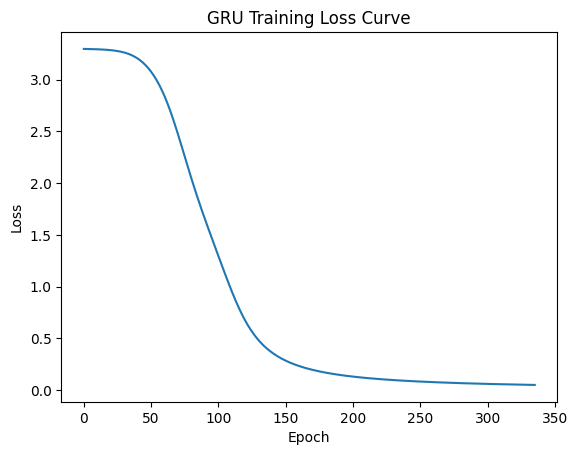

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)

# ------------------------------------------------
# Activation Functions
# ------------------------------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

def cross_entropy(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred + 1e-12))

def clip_gradients(grad, clip_value=5):
    return np.clip(grad, -clip_value, clip_value)

# ------------------------------------------------
# Hyperparameters
# ------------------------------------------------
input_size = 3
hidden_size = 2
output_size = 3

learning_rate = 0.1
max_epochs = 1000
threshold = 0.05

np.random.seed(1)

# ------------------------------------------------
# Initialize GRU Parameters
# ------------------------------------------------
def init_gate():
    return np.random.randn(hidden_size, input_size + hidden_size) * 0.1

Wz = init_gate()
Wr = init_gate()
Wh = init_gate()

bz = np.zeros((hidden_size,1))
br = np.zeros((hidden_size,1))
bh = np.zeros((hidden_size,1))

Why = np.random.randn(output_size, hidden_size) * 0.1
by = np.zeros((output_size,1))

# ------------------------------------------------
# Data (abc → bca)
# ------------------------------------------------
x1 = np.array([[1],[0],[0]])
x2 = np.array([[0],[1],[0]])
x3 = np.array([[0],[0],[1]])
inputs = [x1,x2,x3]

t1 = np.array([[0],[1],[0]])
t2 = np.array([[0],[0],[1]])
t3 = np.array([[1],[0],[0]])
targets = [t1,t2,t3]

loss_history = []

# ====================================================
# TRAINING LOOP
# ====================================================
for epoch in range(max_epochs):

    h = np.zeros((hidden_size,1))

    hs, zs_list, rs_list, h_tildes, ps = [], [], [], [], []
    loss = 0

    # -----------------------
    # FORWARD PASS
    # -----------------------
    for t in range(3):

        z_input = np.vstack((h, inputs[t]))

        z = sigmoid(Wz @ z_input + bz)
        r = sigmoid(Wr @ z_input + br)

        r_h = r * h
        h_input = np.vstack((r_h, inputs[t]))
        h_tilde = np.tanh(Wh @ h_input + bh)

        h = (1 - z) * h + z * h_tilde

        y = Why @ h + by
        p = softmax(y)

        loss += cross_entropy(targets[t], p)

        hs.append(h)
        zs_list.append(z)
        rs_list.append(r)
        h_tildes.append(h_tilde)
        ps.append(p)

    loss_history.append(loss)

    if loss < threshold:
        print("Training converged at epoch:", epoch+1)
        break

    # -----------------------
    # BACKPROPAGATION
    # -----------------------
    dWz = np.zeros_like(Wz)
    dWr = np.zeros_like(Wr)
    dWh = np.zeros_like(Wh)
    dWhy = np.zeros_like(Why)

    dbz = np.zeros_like(bz)
    dbr = np.zeros_like(br)
    dbh = np.zeros_like(bh)
    dby = np.zeros_like(by)

    dh_next = np.zeros((hidden_size,1))

    for t in reversed(range(3)):

        dy = ps[t] - targets[t]
        dWhy += dy @ hs[t].T
        dby += dy

        dh = Why.T @ dy + dh_next

        z = zs_list[t]
        r = rs_list[t]
        h_tilde = h_tildes[t]
        h_prev = hs[t-1] if t > 0 else np.zeros_like(h)

        # h = (1-z)h_prev + z h_tilde
        dh_tilde = dh * z
        dz = dh * (h_tilde - h_prev)

        dh_prev = dh * (1 - z)

        # Candidate derivative
        dh_tilde_raw = dh_tilde * (1 - h_tilde**2)

        r_h_prev = r * h_prev
        h_input = np.vstack((r_h_prev, inputs[t]))

        dWh += dh_tilde_raw @ h_input.T
        dbh += dh_tilde_raw

        dr_h_prev = Wh.T @ dh_tilde_raw
        dr = dr_h_prev[:hidden_size, :]
        dh_prev += dr_h_prev[:hidden_size, :] * r

        dr_raw = dr * r * (1 - r)
        z_input = np.vstack((h_prev, inputs[t]))
        dWr += dr_raw @ z_input.T
        dbr += dr_raw

        dz_raw = dz * z * (1 - z)
        dWz += dz_raw @ z_input.T
        dbz += dz_raw

        dh_next = dh_prev + (Wz.T @ dz_raw)[:hidden_size,:] + \
                  (Wr.T @ dr_raw)[:hidden_size,:]

    # Gradient clipping
    for grad in [dWz,dWr,dWh,dWhy,dbz,dbr,dbh,dby]:
        np.clip(grad, -5, 5, out=grad)

    # Update
    Wz -= learning_rate * dWz
    Wr -= learning_rate * dWr
    Wh -= learning_rate * dWh
    Why -= learning_rate * dWhy

    bz -= learning_rate * dbz
    br -= learning_rate * dbr
    bh -= learning_rate * dbh
    by -= learning_rate * dby

    if (epoch+1) % 100 == 0:
        print("Epoch:", epoch+1, "Loss:", loss)

# ------------------------------------------------
# Final Results
# ------------------------------------------------
print("\nFinal Loss:", loss)
print("\nFinal Predictions:")
for p in ps:
    print(np.round(p,2))

plt.plot(loss_history)
plt.title("GRU Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()